In [95]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [96]:
pd.set_option('display.max_Columns', None)

In [97]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [98]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,on request,sector 103,1.69,9146.0,1848.0,Super Built up area 1845(171.41 sq.m.),3,3,3+,8.0,NaN,Relatively New,1845.0,NaN,NaN,0,0,0,0,0,0,49
1,house,independent,sector 40,5.00,21124.0,2367.0,Plot area 263(219.9 sq.m.),9,9,3+,3.0,North-West,Moderately Old,NaN,263.0,NaN,0,1,1,0,0,1,83
2,house,emaar mgf marbella,sector 66,NaN,NaN,NaN,Plot area 350(292.64 sq.m.)Built Up area: 6500...,4,4,3+,3.0,North,New Property,NaN,6500.0,NaN,1,1,1,1,0,0,136
3,flat,zara aavaas,sector 104,0.20,6645.0,301.0,Built Up area: 301 (27.96 sq.m.),1,1,1,3.0,North-East,Undefined,NaN,301.0,NaN,0,0,0,0,0,0,67
4,house,independent,sector 23,2.80,161849.0,173.0,Plot area 173(16.07 sq.m.)Built Up area: 160 s...,5,5,3+,2.0,North-East,Old Property,NaN,160.0,150.0,0,0,0,1,0,1,74


In [99]:
df.shape

(3677, 23)

In [100]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\3166927754.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

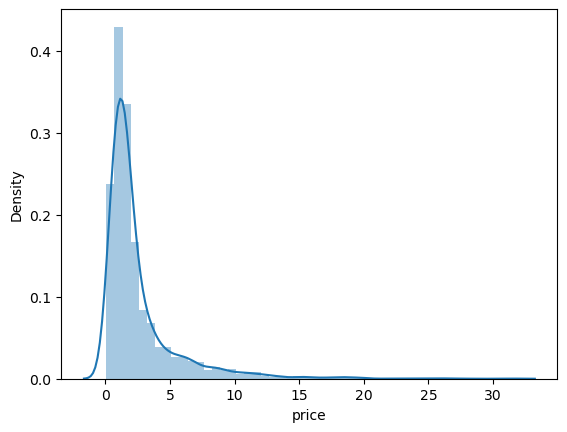

In [101]:
# outliers on the basis of price column 
sns.distplot(df['price'])

<Axes: xlabel='price'>

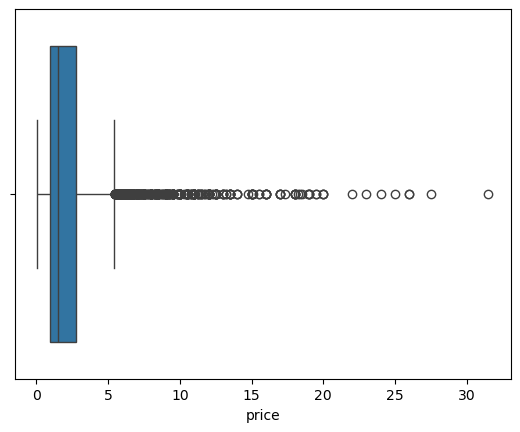

In [102]:
sns.boxplot(x = df['price'])

In [103]:
# calculating the IQR for the price column 
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

In [104]:
# defining the bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [105]:
# Identifying the outliers 
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

In [106]:
# disp;aying the number of outliers and some statistics 
num_outliers = outliers.shape[0]
outliers_price_status = outliers['price'].describe()

In [107]:
num_outliers, outliers_price_status

(425,
 count    425.000000
 mean       9.235624
 std        4.065259
 min        5.460000
 25%        6.460000
 50%        8.000000
 75%       10.750000
 max       31.500000
 Name: price, dtype: float64)

In [108]:
outliers.sort_values('price', ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1834,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately Old,NaN,1000.0,NaN,1,1,1,1,0,2,74
1755,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,NaN,1254.0,NaN,1,1,0,1,1,1,42
2862,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,NaN,505.0,NaN,1,1,0,1,1,1,138
2432,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,1,72
2094,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,NaN,1000.0,NaN,1,1,1,1,0,0,0
2686,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,1,122
2203,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,Relatively New,NaN,1000.0,NaN,1,1,1,1,0,1,145
763,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,NaN,Moderately Old,NaN,1000.0,NaN,0,1,0,0,0,0,54
144,house,independent,sector 26,20.00,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,500.0,NaN,0,1,0,1,0,2,97
662,house,luxury dlf city floors,sector 26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,1,31


In [109]:
# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

# price_per_sqft

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

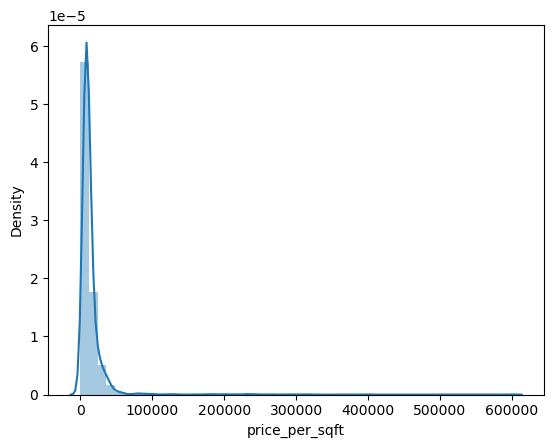

In [110]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

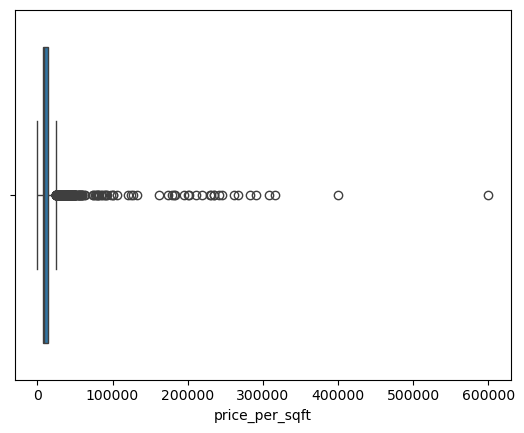

In [111]:
sns.boxplot(x = df['price_per_sqft'])

In [112]:
# calculate the iqr fro the 'price' column
Q1 = df["price_per_sqft"].quantile(0.25)
Q3 = df["price_per_sqft"].quantile(0.75)
IQR = Q3 - Q1

In [113]:
# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [114]:
# Identify outliers
outliers_sqft = df[
    (df["price_per_sqft"] < lower_bound) | (df["price_per_sqft"] > upper_bound)
]

In [115]:
# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft["price_per_sqft"].describe()

In [116]:
num_outliers, outliers_sqft_stats

(354,
 count       354.000000
 mean      52592.612994
 std       61150.458507
 min       24489.000000
 25%       28208.250000
 50%       33368.500000
 75%       41982.250000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [117]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [118]:
outliers_sqft["price_per_sqft"] = round(outliers_sqft["price"] * 10000000)/outliers_sqft['area']

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\1456485765.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft["price_per_sqft"] = round(outliers_sqft["price"] * 10000000)/outliers_sqft['area']


In [119]:
outliers_sqft['price_per_sqft'].describe()

count      354.000000
mean     29357.901761
std      12403.087704
min       2723.311547
25%      25562.372188
50%      29870.794599
75%      35549.095607
max      82539.682540
Name: price_per_sqft, dtype: float64

In [120]:
df.update(outliers_sqft)

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

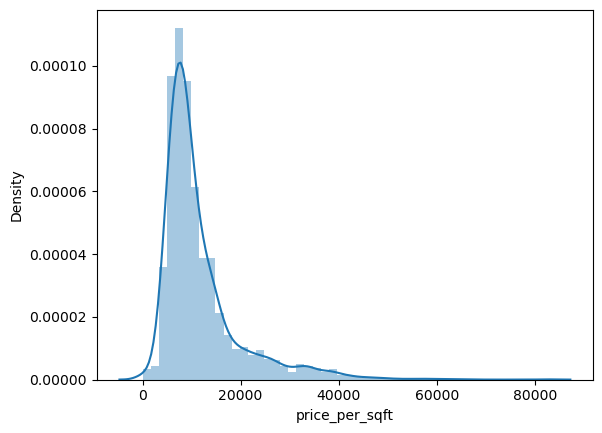

In [121]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

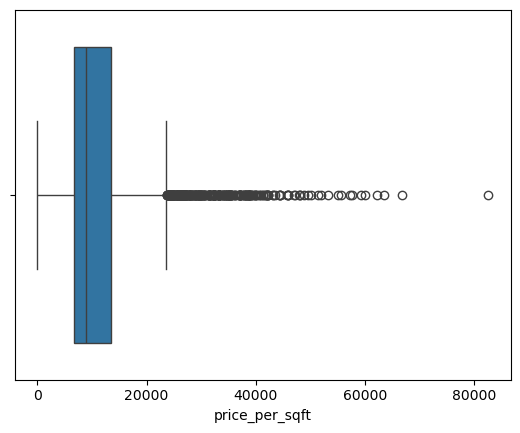

In [122]:
sns.boxplot(x=df['price_per_sqft'])

In [123]:
df[df['price_per_sqft']>50000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
890,house,emaar mgf marbella,sector 66,18.00,55555.555556,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,Moderately Old,NaN,360.0,NaN,1,1,0,1,0,2,75
1362,flat,unitech vistas,sector 70,9.00,57507.987220,1565.0,Built Up area: 1565 (145.39 sq.m.),3,3,0,7.0,NaN,Undefined,NaN,1565.0,NaN,0,0,0,0,0,0,0
1562,house,nul,sector 28,12.50,51440.329218,2430.0,Plot area 270(225.75 sq.m.),16,17,3+,4.0,South,Relatively New,NaN,270.0,NaN,1,1,0,1,1,2,137
1630,house,unitech escape,sector 50,10.80,60000.000000,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,2.0,North,Relatively New,NaN,250.0,200.0,1,1,1,1,0,1,103
1939,house,project housing board colony,sector 31,8.00,63492.063492,1260.0,Built Up area: 140 (117.06 sq.m.),2,1,0,1.0,NaN,Undefined,NaN,140.0,NaN,0,0,0,0,0,0,0
2207,house,cloudnine cottages,sohna road road,5.50,55000.000000,1000.0,Plot area 1000(92.9 sq.m.),3,3,0,1.0,NaN,Moderately Old,NaN,1000.0,NaN,0,0,0,0,0,0,0
2327,house,independent,sector 25,16.00,59259.259259,2700.0,Plot area 350(292.64 sq.m.)Built Up area: 325 ...,16,16,3+,4.0,West,New Property,NaN,325.0,300.0,1,1,1,1,0,1,72
2432,house,independent,sector 26,26.00,82539.682540,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,NaN,400.0,350.0,1,1,1,1,0,1,72
2581,house,independent,sector 26,14.75,51863.572433,2844.0,Plot area 316(264.22 sq.m.),16,20,3+,4.0,East,New Property,NaN,316.0,NaN,1,1,1,1,0,1,153
2686,house,emaar the palm springs,sector 54,24.00,66666.666667,3600.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,NaN,400.0,NaN,1,1,0,1,0,1,122


In [124]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

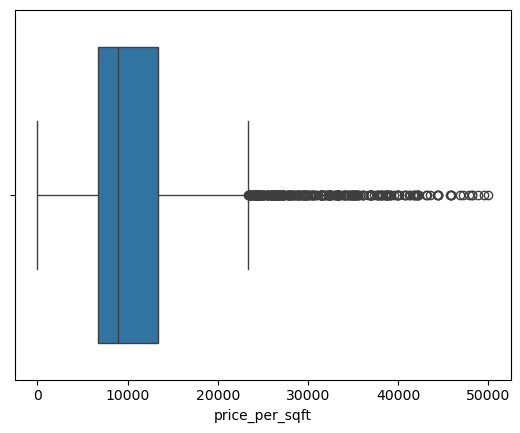

In [125]:
sns.boxplot(x = df['price_per_sqft'])

# Area

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

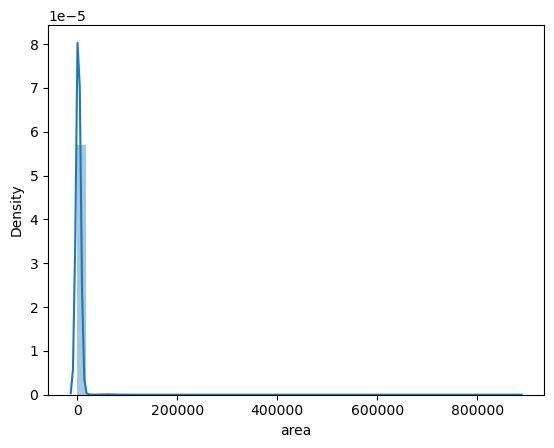

In [126]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

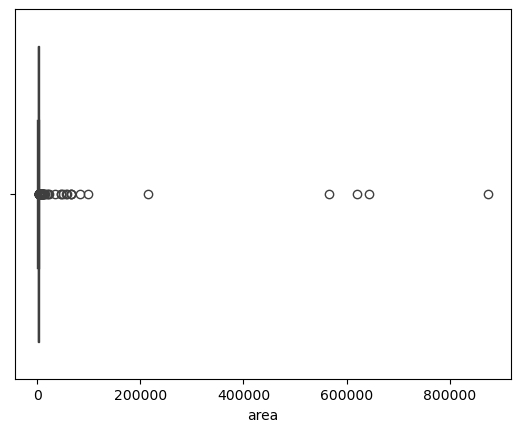

In [127]:
sns.boxplot( x= df['area'])

In [128]:
df[df["area"] > 100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
707,house,independent,sector 50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,NaN,2.0,NaN,1,1,0,1,1,1,0
742,flat,ramsons kshitij,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1,1.0,North-East,Relatively New,NaN,NaN,607936.0,1,0,0,0,1,0,65
1085,flat,hcbs sports ville,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2,8.0,NaN,Relatively New,NaN,737147.0,NaN,0,0,0,0,0,2,44
1174,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1,3.0,North,New Property,NaN,NaN,514396.0,0,0,0,0,0,0,44
3638,flat,signature the roselia,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2,2.0,South-West,New Property,NaN,NaN,569243.0,0,0,0,0,0,0,76


In [129]:
df = df[df["area"] < 100000]

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

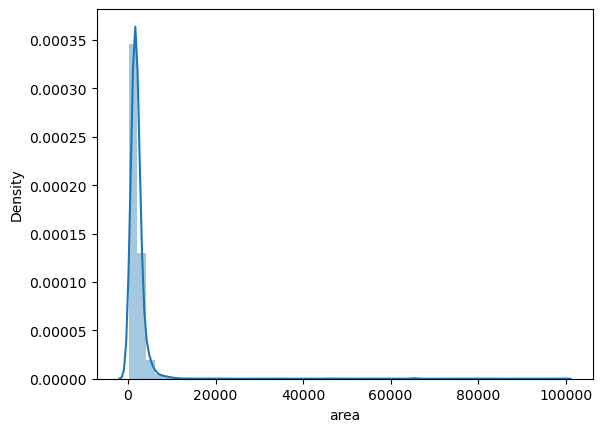

In [130]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

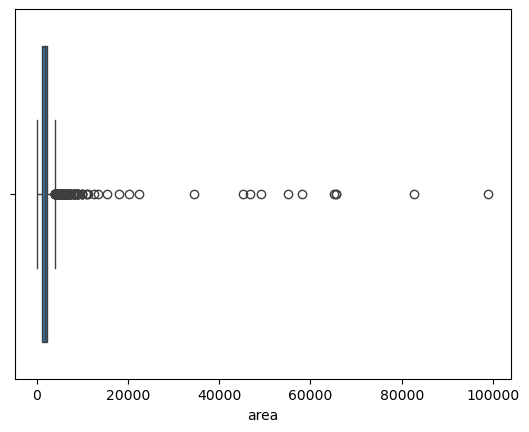

In [131]:
sns.boxplot(x= df['area'])

In [132]:
df[df['area'] > 10000].sort_values('area', ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
723,house,independent,sector 26,18.40,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,NaN,NaN,11000.00,0,1,1,1,0,1,60
38,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
116,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1,12.0,North,Relatively New,NaN,NaN,64412.00,0,0,0,0,0,0,51
441,flat,rof ananda,sector 95,0.38,58.0,65517.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2,10.0,East,New Property,NaN,NaN,64529.00,1,0,0,0,0,0,15
1768,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,0
1783,flat,pyramid elite,sector 86,0.46,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1,0.0,NaN,Under Construction,NaN,NaN,58141.00,0,0,0,0,0,0,15
439,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,0,37
2690,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,0,37
543,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,1,109
3123,flat,ramsons kshitij,sector 95,0.24,53.0,45283.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1,10.0,North-West,Relatively New,NaN,NaN,45966.00,0,0,0,0,1,0,33


In [133]:
df.drop(index= [723, 116, 441, 1783, 2825, 1638, 3123, 1268], inplace= True)

In [134]:
df[df['area'] > 10000].sort_values('area', ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
38,house,ganpati heights apartment,sector 13,1.25,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
1768,house,dlf city plot phase 4,sector 28,13.00,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,NaN,NaN,7250.00,0,0,0,0,0,0,0
439,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.00,0,0,0,0,0,0,37
2690,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.00,1,0,0,0,0,0,37
543,house,independent,sector 25,7.30,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,NaN,5800.0,5200.00,0,1,1,0,0,1,109
2447,house,independent,sector 57,6.25,2778.0,22498.0,Plot area 3100(2591.99 sq.m.)Built Up area: 26...,9,9,3+,3.0,North-East,New Property,NaN,2660.0,2500.00,0,1,0,0,0,1,61
2938,house,independent,sector 43,5.50,2716.0,20250.0,Plot area 215(179.77 sq.m.)Built Up area: 2850...,8,7,3+,3.0,East,Moderately Old,NaN,2850.0,2250.00,1,1,0,1,1,1,123
1530,flat,godrej air,sector 85,2.50,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Undefined,NaN,NaN,18122.00,1,0,0,1,1,1,44
2462,house,unitech aspen greens,sector 50,6.95,4490.0,15479.0,Plot area 240(200.67 sq.m.)Built Up area: 2160...,3,3,1,2.0,North-East,Moderately Old,NaN,2160.0,1720.00,0,1,0,0,0,0,160
3150,flat,godrej icon,sector 88a,1.75,1384.0,12645.0,Carpet area: 1175.11,3,3,3+,6.0,NaN,New Property,NaN,NaN,1175.11,0,0,0,0,0,0,55


In [135]:
df.loc[38, "area"] = 115 * 9
df.loc[1768, "area"] = 7250
df.loc[543, "area"] = 5800
df.loc[2447, "area"] = 2660
df.loc[2938, "area"] = 2850
df.loc[1530, "area"] = 1812
df.loc[2462, "area"] = 2160
df.loc[3150, "area"] = 1175

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

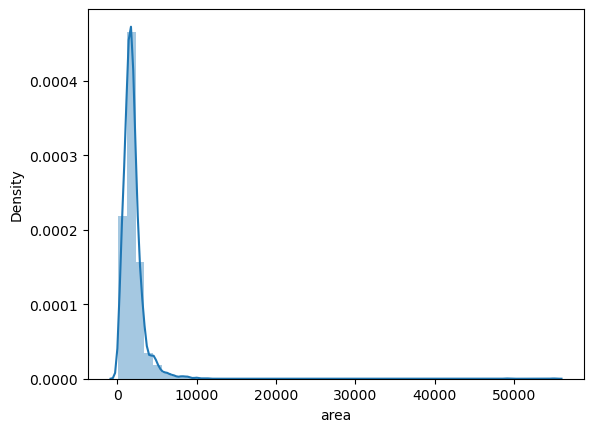

In [136]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

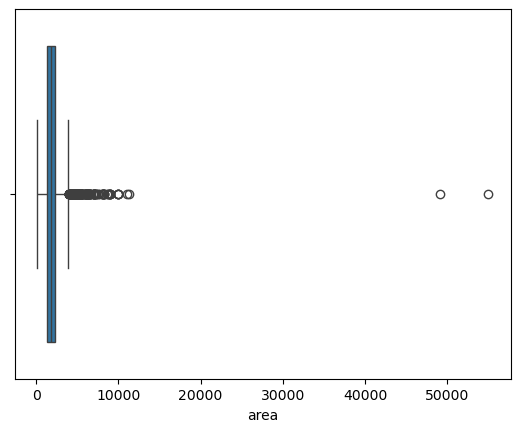

In [137]:
sns.boxplot(x = df['area'])

In [138]:
df['area'].describe()

count     3634.000000
mean      1975.501101
std       1685.973418
min        145.000000
25%       1260.250000
50%       1748.000000
75%       2328.000000
max      55000.000000
Name: area, dtype: float64

# Bedroom

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

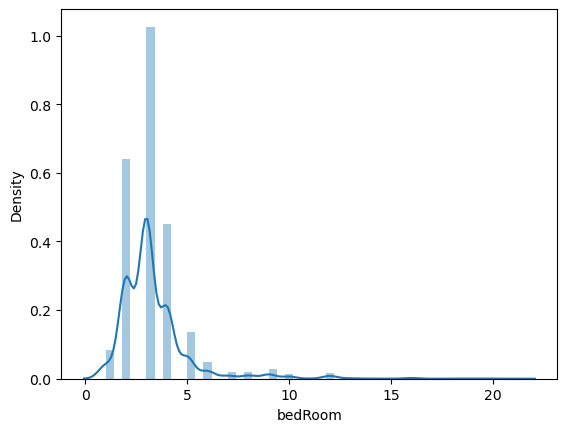

In [139]:
sns.distplot(df['bedRoom'])

<Axes: ylabel='bedRoom'>

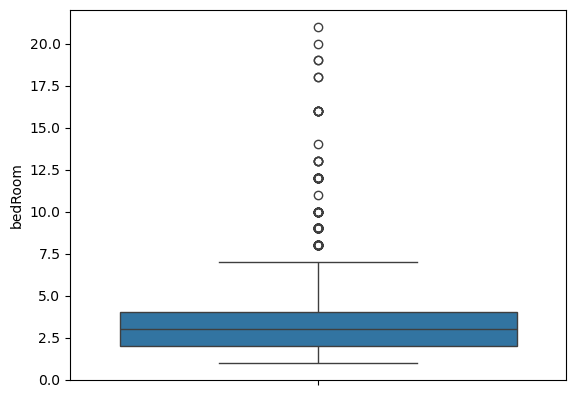

In [140]:
sns.boxplot(df['bedRoom'])

In [141]:
df['bedRoom'].describe()

count    3634.000000
mean        3.332691
std         1.830318
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [142]:
df[df['bedRoom'] > 10].sort_values('bedRoom', ascending= False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
823,house,independent,sector 54,5.00,43066.322136,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,NaN,129.0,NaN,0,1,0,0,0,2,49
75,house,independent,sector 43,4.50,39062.500000,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,NaN,128.0,NaN,0,1,0,0,0,2,22
1439,house,independent,sector 17a,3.87,5160.000000,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,NaN,7500.0,NaN,1,0,1,0,0,0,68
533,house,independent,sector 17a,3.93,24214.000000,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,Relatively New,NaN,1622.0,NaN,1,1,1,1,0,0,74
2010,house,independent,sector 54,5.50,38194.444444,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,NaN,160.0,NaN,0,1,0,0,0,2,70
1851,house,private house,sector 55,7.05,46906.187625,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,NaN,167.0,NaN,0,0,0,0,1,2,57
523,house,dlf city plots,sector 26,20.00,44267.374945,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,NaN,502.0,NaN,1,1,1,1,0,1,153
1533,house,independent,sector 55,9.19,34037.037037,2700.0,Plot area 300(250.84 sq.m.),16,18,2,4.0,West,New Property,NaN,300.0,NaN,0,1,0,1,0,1,49
789,house,independent,sector 43,13.50,50000.000000,2700.0,Plot area 300(250.84 sq.m.),16,16,3+,4.0,North-West,Relatively New,NaN,300.0,NaN,1,1,0,1,1,0,41
662,house,luxury dlf city floors,sector 26,20.00,48887.802493,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,NaN,500.0,NaN,0,1,0,0,0,1,31


In [143]:
df = df[df['bedRoom'] <= 10]

In [144]:
df.shape

(3589, 23)

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

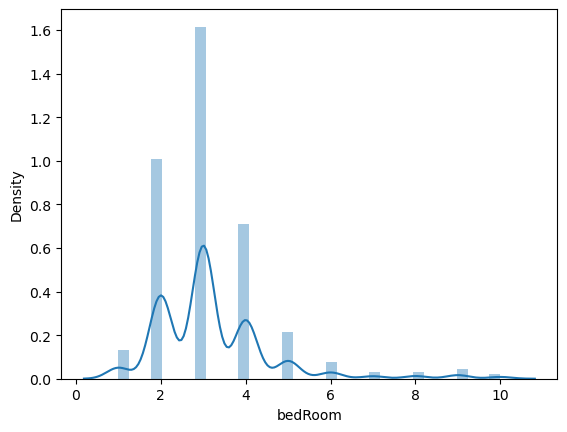

In [145]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

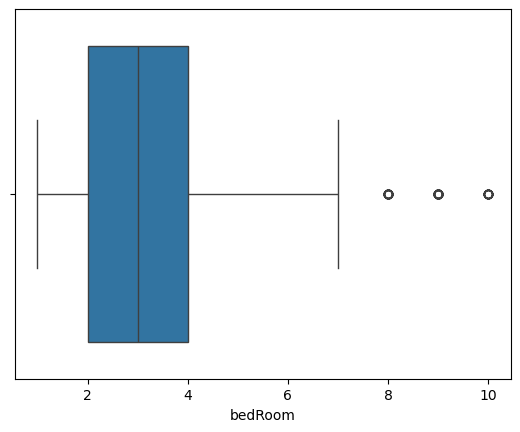

In [146]:
sns.boxplot( x= df['bedRoom'])

In [147]:
df['bedRoom'].describe()

count    3589.000000
mean        3.202842
std         1.394400
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        10.000000
Name: bedRoom, dtype: float64

# Bathroom

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

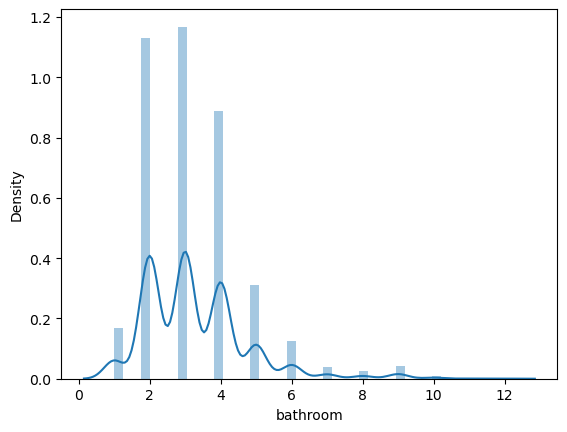

In [148]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

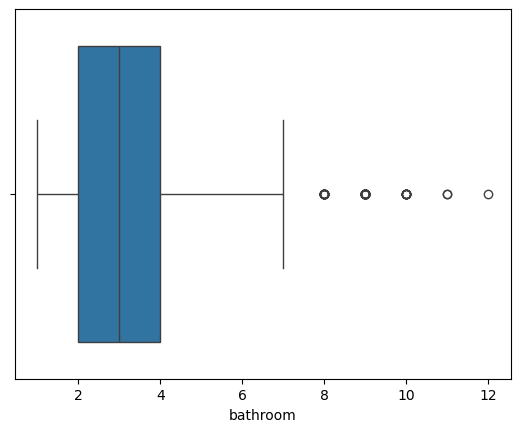

In [149]:
sns.boxplot(x = df['bathroom'])

In [150]:
df[df['bathroom'] > 10].sort_values('bathroom', ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
725,house,adani brahma samsara,sector 60,18.02,28200.312989,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,NaN,6390.0,NaN,0,1,0,0,0,1,146
172,house,independent,sector 24,11.00,28901.734104,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.0,East,Old Property,NaN,5000.0,NaN,1,1,0,1,1,1,39
3179,house,independent,sector 39,7.00,10000.000000,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,Relatively New,NaN,7000.0,NaN,0,0,0,1,0,1,38


# super built up area

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

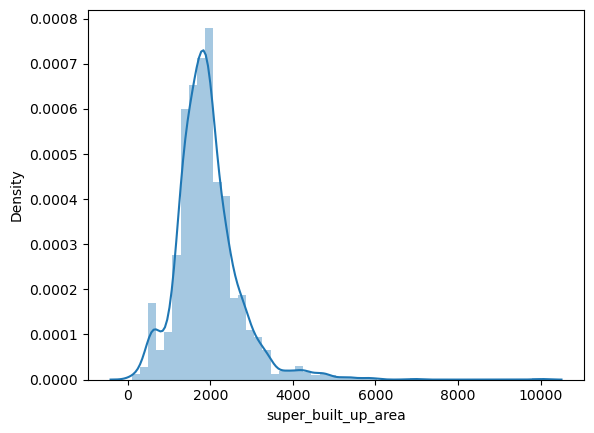

In [151]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

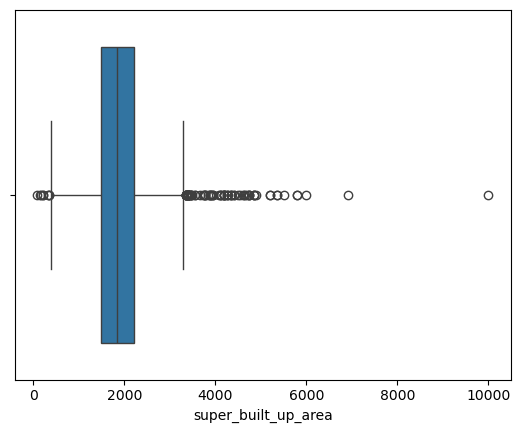

In [152]:
sns.boxplot( x= df['super_built_up_area'])

In [153]:
df['super_built_up_area'].describe()

count     1875.000000
mean      1925.237627
std        764.172177
min         89.000000
25%       1479.500000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [154]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
181,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+,23.0,North-East,Relatively New,10000.0,NaN,NaN,0,1,0,1,1,0,49
1871,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+,19.0,North,Relatively New,6926.0,NaN,NaN,0,1,0,0,0,1,140


# built up area

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

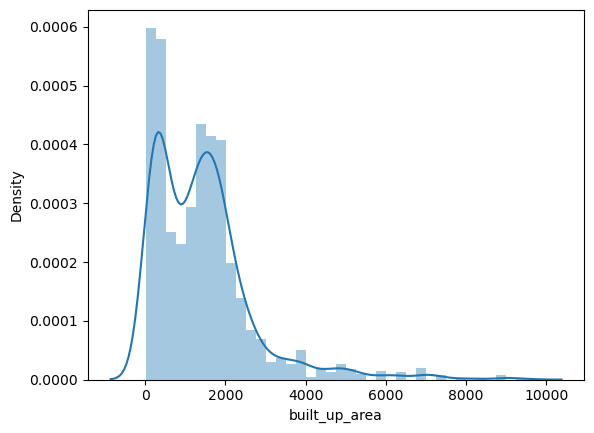

In [155]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

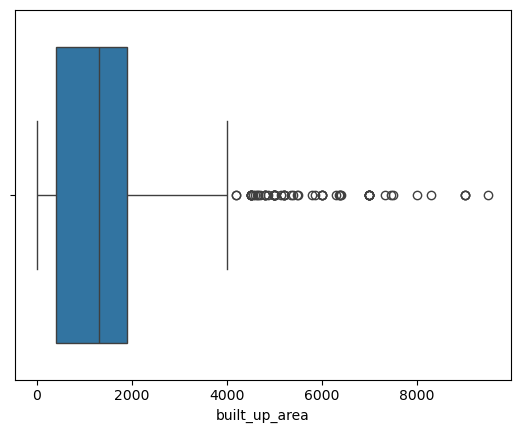

In [156]:
sns.boxplot(x= df['built_up_area'])

In [157]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score


# carpet area

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

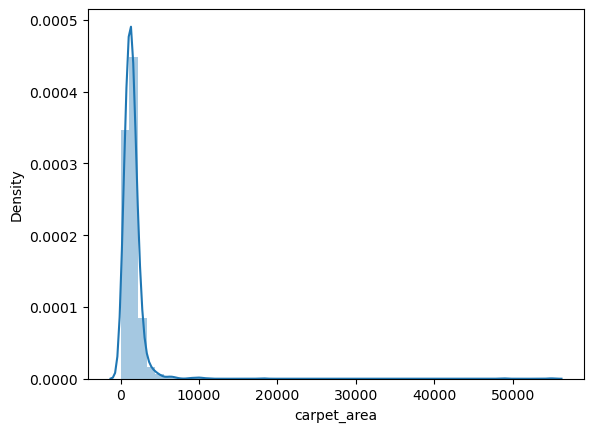

In [158]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

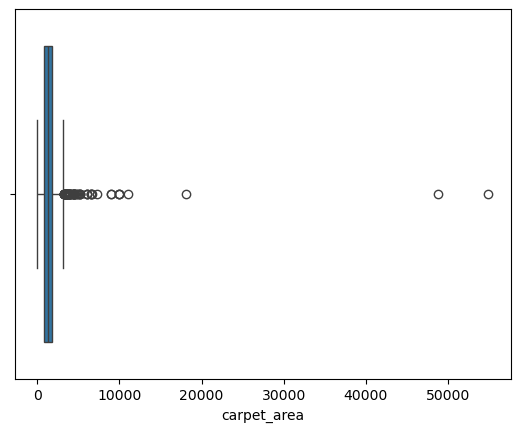

In [159]:
sns.boxplot(x = df['carpet_area'])

In [160]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
439,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.0,0,0,0,0,0,0,37
1530,flat,godrej air,sector 85,2.50,1379.0,1812.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+,16.0,North-East,Undefined,NaN,NaN,18122.0,1,0,0,1,1,1,44
1922,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,0,60
2690,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.0,1,0,0,0,0,0,37


In [161]:
df.loc[1530, 'carpet_area'] = 1812

In [162]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
439,flat,rof ananda,sector 95,0.33,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1,13.0,South-West,Relatively New,NaN,NaN,54917.0,0,0,0,0,0,0,37
1922,flat,m3m golfestate,sector 65,13.20,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3,13.0,North,Moderately Old,NaN,NaN,11000.0,0,1,0,0,0,0,60
2690,flat,signature the serenas,sohna road,0.28,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2,1.0,North-West,Relatively New,NaN,NaN,48811.0,1,0,0,0,0,0,37


C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

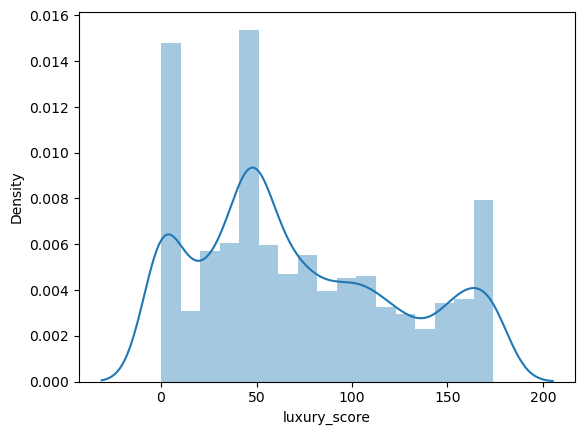

In [163]:
sns.distplot(df['luxury_score'])

<Axes: ylabel='luxury_score'>

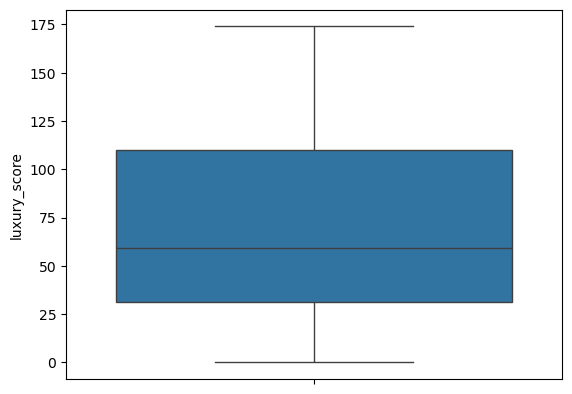

In [164]:
sns.boxplot(df['luxury_score'])

In [165]:
df.shape

(3589, 23)

In [166]:
df["price_per_sqft"] = round(df["price"] * 10000000) /df['area']

In [167]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,on request,sector 103,1.69,9145.021645,1848.0,Super Built up area 1845(171.41 sq.m.),3,3,3+,8.0,NaN,Relatively New,1845.0,NaN,NaN,0,0,0,0,0,0,49
1,house,independent,sector 40,5.00,21123.785382,2367.0,Plot area 263(219.9 sq.m.),9,9,3+,3.0,North-West,Moderately Old,NaN,263.0,NaN,0,1,1,0,0,1,83
3,flat,zara aavaas,sector 104,0.20,6644.518272,301.0,Built Up area: 301 (27.96 sq.m.),1,1,1,3.0,North-East,Undefined,NaN,301.0,NaN,0,0,0,0,0,0,67
4,house,independent,sector 23,2.80,17983.301220,1557.0,Plot area 173(16.07 sq.m.)Built Up area: 160 s...,5,5,3+,2.0,North-East,Old Property,NaN,160.0,150.0,0,0,0,1,0,1,74
5,house,independent,sector 47,5.15,26614.987080,1935.0,Plot area 215(179.77 sq.m.),9,9,3+,3.0,East,Relatively New,NaN,215.0,NaN,0,0,1,0,0,1,75


C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

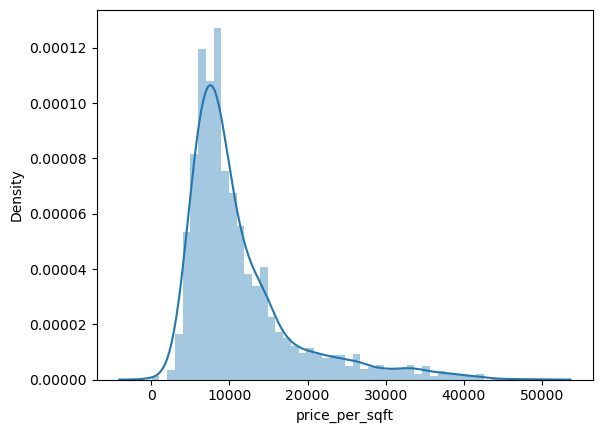

In [168]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

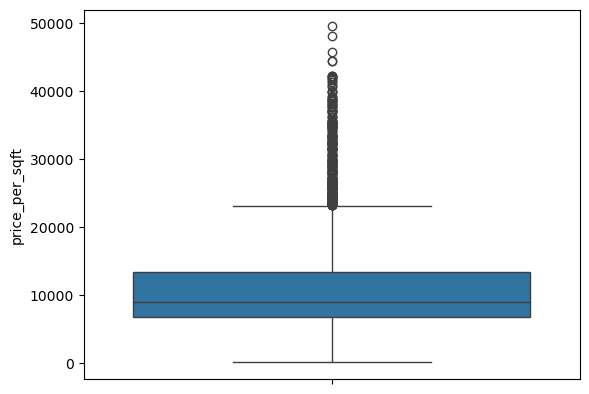

In [169]:
sns.boxplot(df['price_per_sqft'])

In [170]:
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
144,house,independent,sector 26,20.0,44444.444444,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,NaN,500.0,NaN,0,1,0,1,0,2,97
154,house,sushant lok 1 builder floors,sector 43,13.0,48148.148148,2700.0,Plot area 300(250.84 sq.m.),3,3,3+,4.0,North,New Property,NaN,300.0,NaN,0,0,0,1,0,1,7
1250,house,independent,sector 25,13.0,45710.267229,2844.0,Plot area 316(264.22 sq.m.),6,8,3+,NaN,NaN,Relatively New,NaN,316.0,NaN,1,1,1,1,0,2,0
1368,house,independent,sector 105,9.9,49500.000000,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,2,3.0,North,Undefined,NaN,2000.0,1800.0,0,0,0,0,0,0,0
2006,house,independent,sector 26,19.0,42222.222222,4500.0,Plot area 500(418.06 sq.m.),6,8,3+,3.0,East,Moderately Old,NaN,500.0,NaN,1,1,1,1,0,1,103
2869,house,independent,sector 28,12.0,42194.092827,2844.0,Plot area 316(264.22 sq.m.),4,5,3+,4.0,East,Relatively New,NaN,316.0,NaN,0,1,1,1,0,1,60
2951,house,dlf city plots,sector 26,19.0,42054.006197,4518.0,Plot area 502(419.74 sq.m.),6,6,3,2.0,East,Relatively New,NaN,502.0,NaN,1,1,0,0,0,1,121
3103,house,independent,sector 55,5.0,44444.444444,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,New Property,NaN,115.0,100.0,0,0,0,0,1,1,44
3223,house,independent,sector 43,9.5,42222.222222,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5,5,3+,2.0,North-East,Relatively New,NaN,300.0,250.0,0,1,0,1,0,1,88


In [171]:
x = df[df['price_per_sqft'] <= 20000]

In [172]:
(x['area']/x['bedRoom'].quantile(0.02))

0       1848.0
3        301.0
4       1557.0
6       1426.0
7       1568.0
         ...  
3796     547.0
3797     481.0
3800    1960.0
3801    2100.0
3802    1365.0
Name: area, Length: 3201, dtype: float64

In [173]:
df[(df['area']/df['bedRoom']) <183]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
10,house,sector 57 huda,sector 57,3.80,26063.100137,1458.0,Plot area 162(135.45 sq.m.)Built Up area: 162 ...,8,8,3+,4.0,East,Relatively New,NaN,162.0,160.0,0,0,1,1,0,1,94
38,house,ganpati heights apartment,sector 13,1.25,12077.294686,1035.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,NaN,115.0,NaN,0,0,0,0,1,0,7
41,house,independent,sector 41,4.25,26234.567901,1620.0,Plot area 180(150.5 sq.m.),10,9,3+,4.0,North,Moderately Old,NaN,180.0,NaN,1,1,0,0,0,1,36
187,house,independent,sohna road road,1.20,22304.832714,538.0,Plot area 50,4,4,3+,4.0,West,Old Property,NaN,50.0,NaN,0,0,0,0,0,0,8
190,house,independent,sector 2,1.00,8230.452675,1215.0,Plot area 135(112.88 sq.m.),9,7,3+,3.0,North,Moderately Old,NaN,135.0,NaN,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3470,house,ss omnia,sector 86,0.42,9333.333333,450.0,Plot area 50(4.65 sq.m.),5,3,2,3.0,NaN,Relatively New,NaN,50.0,NaN,0,0,0,0,0,0,0
3512,house,independent,sector 17,0.32,5663.716814,565.0,Built Up area: 565 (52.49 sq.m.),5,1,0,1.0,NaN,Undefined,NaN,565.0,NaN,0,0,0,0,0,0,0
3568,house,shri shyam residency,sector 104,0.62,12400.000000,500.0,Plot area 500(46.45 sq.m.)Built Up area: 900 s...,3,3,1,2.0,NaN,Moderately Old,NaN,900.0,480.0,0,0,0,0,1,2,8
3647,house,sector 38 rwa,sector 38,1.40,23931.623932,585.0,Plot area 65(54.35 sq.m.)Built Up area: 62 sq....,8,8,3,4.0,East,Moderately Old,NaN,62.0,60.0,0,0,0,0,1,1,40


In [174]:
x = df[df['price_per_sqft'] <=20000]

In [175]:
(x['area']/x['bedRoom']).quantile(0.05)

250.5

In [176]:
df[df['area']/df['bedRoom'] < 250].sample(5)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3008,flat,conscient habitat,sector 99a,0.27,5601.659751,482.0,Carpet area: 484 (44.97 sq.m.),2,2,1,8.0,South-West,Relatively New,NaN,NaN,484.0,0,0,0,0,1,0,49
1476,flat,signature global solera,sector 107,0.51,7906.976744,645.0,Carpet area: 645 (59.92 sq.m.),3,2,2,9.0,South,Relatively New,NaN,NaN,645.0,0,0,0,0,1,0,15
1881,house,iffco nagar and 17b rwa,sector 17,2.98,20565.907522,1449.0,Plot area 161(134.62 sq.m.),6,6,3+,3.0,East,Relatively New,NaN,161.0,NaN,1,0,0,1,0,0,78
3014,house,ashok vihar phase iii extension,sector 3 phase 3 extension,0.40,8888.888889,450.0,Plot area 50(41.81 sq.m.),7,4,3+,4.0,NaN,New Property,NaN,50.0,NaN,0,0,0,1,0,0,7
2243,house,independent,sector 28,0.45,10000.000000,450.0,Built Up area: 50 (4.65 sq.m.),5,3,0,1.0,NaN,Undefined,NaN,50.0,NaN,0,0,0,0,0,0,0


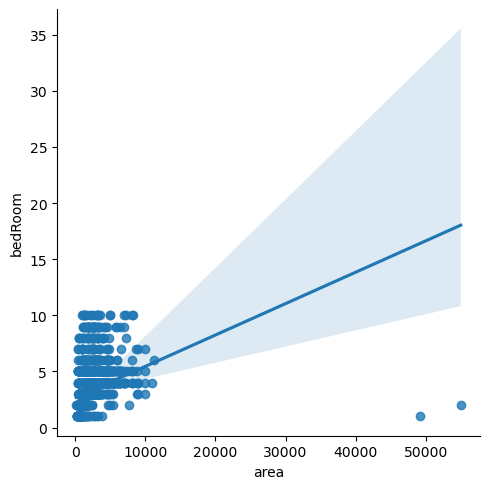

In [177]:
sns.lmplot(data=df, x='area', y= 'bedRoom')

In [178]:
df['area_room_ratio'] = df['area']/df['bedRoom']

In [179]:
(df[df['area_room_ratio'] < 250])['bedRoom'].value_counts()

bedRoom
2     47
3     33
5     28
6     17
4     17
9     15
8     12
10     8
7      8
Name: count, dtype: int64

In [180]:
df = df[df['area_room_ratio'] > 100]

In [181]:
outliers_df = df[(df['area_room_ratio'] < 250) & (df['bedRoom'] > 3)]

In [182]:
outliers_df['bedRoom'] = round(outliers_df['bedRoom']/outliers_df['floorNum'])

C:\Users\ACER\AppData\Local\Temp\ipykernel_1400\3450078040.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_df['bedRoom'] = round(outliers_df['bedRoom']/outliers_df['floorNum'])


In [183]:
df.update(outliers_df)

In [184]:
df['area_room_ratio'] = df['area']/df['bedRoom']

In [185]:
df[(df['area_room_ratio'] < 250) & (df['bedRoom'] > 4)]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
254,house,independent,manesar,1.10,6172.839506,1782.0,Plot area 1782(165.55 sq.m.),8,8,0,1.0,NaN,New Property,NaN,1782.0,NaN,0,0,0,0,0,0,0,222.750000
567,house,independent,manesar,0.80,6666.666667,1200.0,Plot area 1200(111.48 sq.m.),8,8,2,1.0,NaN,Relatively New,NaN,1200.0,NaN,0,0,0,0,0,0,0,150.000000
654,house,independent,sector 7,1.16,11717.171717,990.0,Carpet area: 110 (91.97 sq.m.),5,4,2,1.0,North-East,Undefined,NaN,NaN,110.0,0,0,0,0,0,0,0,198.000000
941,house,independent,sector 12,0.65,6500.000000,1000.0,Carpet area: 1000 (92.9 sq.m.),6,2,3,1.0,NaN,Undefined,NaN,NaN,1000.0,0,0,0,0,0,0,0,166.666667
1173,house,independent,sector 3 phase 2,0.85,9444.444444,900.0,Carpet area: 900 (83.61 sq.m.),5,3,3,1.0,NaN,Undefined,NaN,NaN,900.0,0,0,0,0,0,0,0,180.000000
1316,house,independent,sector 3 phase 2,1.10,10000.000000,1100.0,Built Up area: 1100 (102.19 sq.m.)Carpet area:...,5,4,2,1.0,East,Undefined,NaN,1100.0,900.0,0,0,0,0,0,0,0,220.000000
2008,house,independent,sector 105,1.10,12222.222222,900.0,Carpet area: 900 (83.61 sq.m.),6,4,1,1.0,South-West,Undefined,NaN,NaN,900.0,0,0,0,0,0,0,0,150.000000
2079,house,independent,sector 2,0.98,9074.074074,1080.0,Carpet area: 120 (100.34 sq.m.),9,4,3,1.0,South,Undefined,NaN,NaN,120.0,0,0,0,0,0,0,0,120.000000
2252,house,shivpuri,sector 7,2.80,12444.444444,2250.0,Plot area 2250(209.03 sq.m.),10,7,3,1.0,NaN,Old Property,NaN,2250.0,NaN,1,1,0,1,1,1,0,225.000000
2419,house,independent,sector 12,2.50,13888.888889,1800.0,Plot area 1800(167.23 sq.m.),9,5,2,1.0,South-East,Old Property,NaN,1800.0,NaN,0,0,0,1,0,0,8,200.000000


In [186]:
df[(df["area_room_ratio"] < 250) & (df["bedRoom"] > 4)].shape

(13, 24)

In [187]:
df.shape

(3569, 24)

In [188]:
df = df[~((df['area_room_ratio'] < 250) & (df['bedRoom'] > 4))]

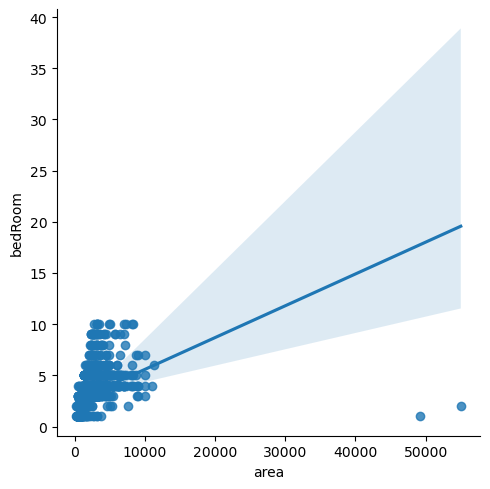

In [189]:
sns.lmplot(data= df, x='area', y='bedRoom')

In [190]:
df.to_csv('gurgaon_properties_outlier_treated.csv' , index= False)